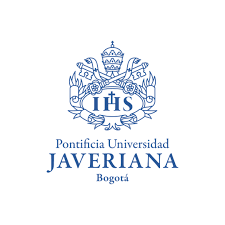
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Mariana Rodriguez

Fecha de Inicio: 

Fecha actual: 

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

In [1]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable


In [4]:
### Levantamiento de variables de entorno pip
import os

import sys
sys.path.append('/usr/lib/python3/dist-packages/')
import numpy as np
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *

In [5]:
### Levantamiento de sesión SPARK
configura = SparkConf()

configura.setAppName("Calidad_Agua_Rodriguez")

sparkRodriguez = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkRodriguez.sparkContext, sparkSession=sparkRodriguez)

sparkContextoS = sparkRodriguez.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkRodriguez

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 20:03:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


In [6]:
##**2.- Carga de Datos desde el HADOOP HDFS**

!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkRodriguez.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

df00.show(5)

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


[Stage 1:>                                                          (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [7]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

**Se presenta las estadísticas de los datos a continuación:**

In [8]:
for valor in df00.columns:
  
  df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+



+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|              13.2|
|    max|               9.1|
+-------+------------------

+-------+-----------------+
|summary|   FECAL_COLIFORM|
+-------+-----------------+
|  count|              534|
|   mean|7384.170353982301|
| stddev|30714.05963523712|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|    TOTAL_COLIFORM|
+-------+------------------+
|  count|               534|
|   mean|124396.96767676767|
| stddev|1458407.8189939584|
|    min|                 1|
|    max|                NA|
+-------+------------------+



## **Visualización de los DATOS NULOS**

#Cantidad de Valores Nulos o Imposibles

In [9]:
df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+




* Se observa que no hay datos nulos o imposibles
* Se procede a Graficar cada una de las dimensiones

In [10]:
##Se crea una vista para ser usada en las visualizaciones 
df00.createOrReplaceTempView("df00_sql")
df01 = sparkRodriguez.sql('''Select * from df00_sql where TEMP is not null and DO is not null and pH is not null and CONDUCTIVITY is not null and BOD is not null and NITRATE_N_NITRITE_N is not null and FECAL_COLIFORM is not null''')

In [11]:
#Se verifica la Cantidad de Valores Nulos o Imposibles
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### **Tratamiento de datos**

In [12]:
df00.dtypes

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'string'),
 ('DO', 'string'),
 ('pH', 'string'),
 ('CONDUCTIVITY', 'string'),
 ('BOD', 'string'),
 ('NITRATE_N_NITRITE_N', 'string'),
 ('FECAL_COLIFORM', 'string'),
 ('TOTAL_COLIFORM', 'string')]

In [13]:
##Se procede a cambiar los tipos de datos
df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))

In [14]:
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))

In [15]:
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))

In [16]:
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))

In [17]:
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))

In [18]:
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))

In [19]:
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))

In [20]:
df00.dtypes

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'float'),
 ('DO', 'float'),
 ('pH', 'float'),
 ('CONDUCTIVITY', 'float'),
 ('BOD', 'float'),
 ('NITRATE_N_NITRITE_N', 'float'),
 ('FECAL_COLIFORM', 'float'),
 ('TOTAL_COLIFORM', 'string')]

In [21]:
##Se elimina la columna TOTAL_COLIFORM
df01 = df00.drop('TOTAL_COLIFORM')
df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

## **Creación de Tablas para Visualizar los Datos**

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos
- 
- pH
- CONDUCTIVITY
- BOD
- NITRATE_N_NITRITE_N
- FECAL_COLIFORM 

In [22]:
df01.createOrReplaceTempView("df01_sql")

In [23]:
###Se crea una consulta por cada parámetro DO

do_parametro = sparkRodriguez.sql("Select DO from df01_sql")

In [24]:
do_parametro = sparkRodriguez.sql("Select DO from df01_sql").rdd.map(lambda fila: fila.DO).collect()
ph_parametro = sparkRodriguez.sql("Select pH from df01_sql").rdd.map(lambda fila: fila.pH).collect()
BOD_parametro = sparkRodriguez.sql("Select BOD from df01_sql").rdd.map(lambda fila: fila.BOD).collect()
NN_parametro = sparkRodriguez.sql("Select NITRATE_N_NITRITE_N from df01_sql").rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()
COND_parametro = sparkRodriguez.sql("Select CONDUCTIVITY from df01_sql").rdd.map(lambda fila: fila.CONDUCTIVITY).collect()
FC_parametro = sparkRodriguez.sql("Select FECAL_COLIFORM from df01_sql").rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()

26/04/27 20:03:47 WARN TaskSetManager: Lost task 0.0 in stage 42.0 (TID 29) (10.43.101.26 executor 2): java.io.IOException: Cannot run program "/usr/bin/python": error=2, No such file or directory
	at java.lang.ProcessBuilder.start(ProcessBuilder.java:1048)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.computeOrReadCheckpoint(RDD.scala:367)
	at org.apache.spark.rdd.RDD.iterator(RDD.scala:331)
	at org.apache.spark.scheduler.ResultTask.runTask(ResultTask.scala:93)
	at org.apache.spark.TaskContext.runTaskWi

* ###Grafica Los parámetros para conocer sus características: DO y PH

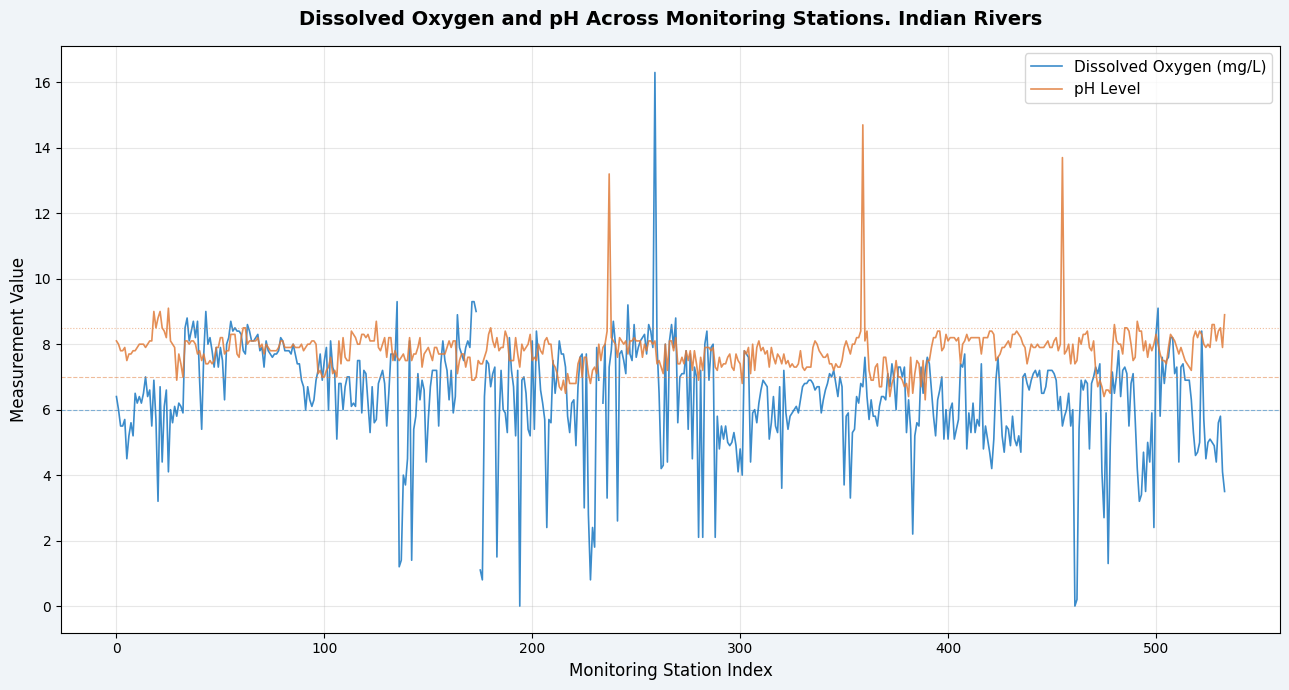

In [25]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='#f0f4f8', edgecolor='k')

ax1.plot(range(0,tam), do_parametro, label='Dissolved Oxygen (mg/L)', color='#1a78c2', linewidth=1.2, alpha=0.85)
ax1.plot(range(0,tam), ph_parametro, label='pH Level', color='#e07b39', linewidth=1.2, alpha=0.85)

ax1.set_title('Dissolved Oxygen and pH Across Monitoring Stations. Indian Rivers', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Monitoring Station Index', fontsize=12)
ax1.set_ylabel('Measurement Value', fontsize=12)
ax1.legend(fontsize=11)
ax1.axhline(y=6, color='#1a78c2', linestyle='--', linewidth=0.8, alpha=0.5, label='Min safe DO')
ax1.axhline(y=7, color='#e07b39', linestyle='--', linewidth=0.8, alpha=0.5, label='Min safe pH')
ax1.axhline(y=8.5, color='#e07b39', linestyle=':', linewidth=0.8, alpha=0.5, label='Max safe pH')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* ###Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos

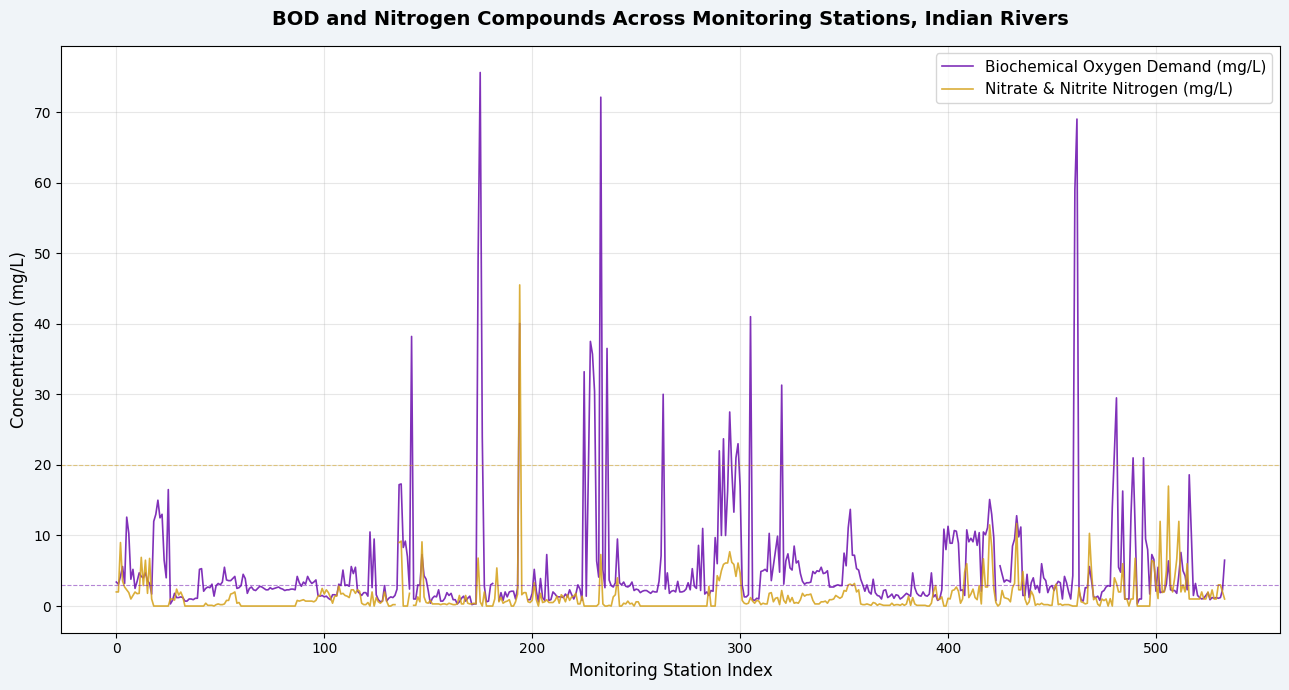

In [26]:
tam = len(BOD_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='#f0f4f8', edgecolor='k')

ax1.plot(range(0,tam), BOD_parametro, label='Biochemical Oxygen Demand (mg/L)', color='#6a0dad', linewidth=1.2, alpha=0.85)
ax1.plot(range(0,tam), NN_parametro, label='Nitrate & Nitrite Nitrogen (mg/L)', color='#d4a017', linewidth=1.2, alpha=0.85)

ax1.set_title('BOD and Nitrogen Compounds Across Monitoring Stations, Indian Rivers', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Monitoring Station Index', fontsize=12)
ax1.set_ylabel('Concentration (mg/L)', fontsize=12)
ax1.axhline(y=3, color='#6a0dad', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axhline(y=20, color='#d4a017', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

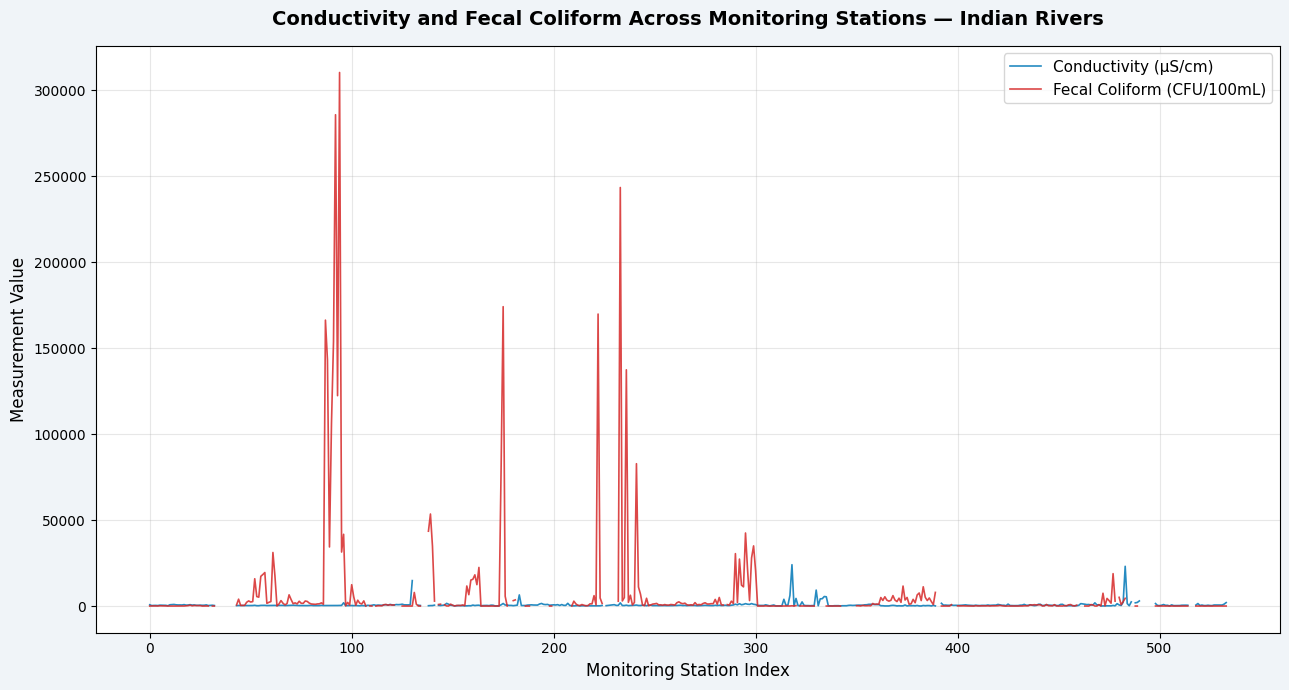

In [27]:
tam = len(COND_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='#f0f4f8', edgecolor='k')

ax1.plot(range(0,tam), COND_parametro, label='Conductivity (µS/cm)', color='#0077b6', linewidth=1.2, alpha=0.85)
ax1.plot(range(0,tam), FC_parametro, label='Fecal Coliform (CFU/100mL)', color='#d62828', linewidth=1.2, alpha=0.85)

ax1.set_title('Conductivity and Fecal Coliform Across Monitoring Stations — Indian Rivers', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Monitoring Station Index', fontsize=12)
ax1.set_ylabel('Measurement Value', fontsize=12)
ax1.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
#Función definida por el usuario para definir el rango de calidad de agua según el pH
#Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).

       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

In [29]:
### Función definida por el usuario para definir el rando de la calidad del agua según DO
df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
                    when((df01.DO>=5.1) & (df01.DO<6.0), 80).
                    when((df01.DO>=4.1) & (df01.DO<5.0), 60).
                    when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

In [30]:
### Función definida por el usuario para definir el rando de la calidad del agua según COND
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
          when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
          when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
          when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

In [31]:
### Función definida por el usuario para definir el rando de la calidad del agua según BOD
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
                     when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
                     when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
                     when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

In [32]:
### Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N
### 100: Agua Dulce
### 80: Agua Moderada
### 60: Agua Dura
### 40: Agua muy Dura
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
                     when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
                     when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
                     when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

In [33]:
### Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
### 100: Agua Dulce
### 80: Agua Moderada
### 60: Agua Dura
### 40: Agua muy Dura

df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
                    when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
                    when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
                    when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

In [34]:
##**El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

#A continuación se hace una inspección en general del df02
df02.show(10)
##Nombre de Columnas
df02.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

In [35]:
## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

###Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

df03.show(10)
df03.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculo del Índice de Calidad del Agua**

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

In [36]:
df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***

In [37]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente').when((df04.WQI>=25) & (df04.WQI<50),'Buena').when((df04.WQI>=50) & (df04.WQI<75),'Baja').when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja').otherwise('Inadecuada')
                      )
df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

In [38]:
#Impresión de nombre de regiones sobre el mapa
colEstado = 'STATE'
valNomnbres = df05.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)


['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Se cargan los datos de los mapas disponibles**

- Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

In [39]:
import sys
!{sys.executable} -m pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [40]:
import geopandas as gpd

rutaMapas = "/home/estudiante/Documents/WaterQuality_ML/Indian_States.shp"

## Se carga un objeto dataframe de los datos comprimidos de los mapas
gpd01 = gpd.read_file(rutaMapas)

## Se visualiza el tipo de dataframe que da geopandas y las columnas 
print(type(gpd01))
gpd01.columns

<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

In [41]:
#Se visualizan los nombres de la columna de los estados "st_nm"
gpd01["st_nm"].unique()

### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan 
### con los nombres de los estados del dataframe de datos inicial

gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                     'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                    'Daman & Diu': 'Daman Diu', 
                     'Jammu & Kashmir': 'Jammu Kashmir',
                     'NCT of Delhi' : 'Delhi'
                      })
gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [42]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [43]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

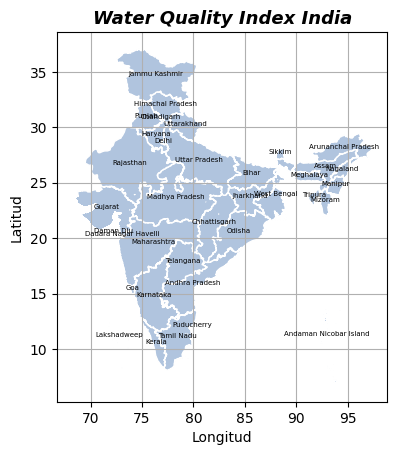

In [44]:
ax = dfMAP.plot(color='lightsteelblue', edgecolor='white', missing_kwds={'color': 'lightgrey'})
plt.title("Water Quality Index India", fontsize=13, style='italic', fontweight='bold')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()

for idx, row in dfMAP.iterrows():
    ax.annotate(row['STATE'], xy=row['geometry'].centroid.coords[0],
                ha='center', fontsize=5)

plt.show()

## Análisis
### - El mapa base confirma que el shapefile cubre correctamente las 18 regiones
###   administrativas del dataset, incluyendo territorios insulares.
### - Las etiquetas por estado permiten identificar rápidamente la ubicación
###   geográfica de cada región antes de superponer los datos de calidad.
### - Estados del noreste (Assam, West Bengal) y del sur (Kerala, Tamil Nadu)
###   son geográficamente pequeños pero tienen alta densidad de estaciones
###   de monitoreo en el dataset.

In [45]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


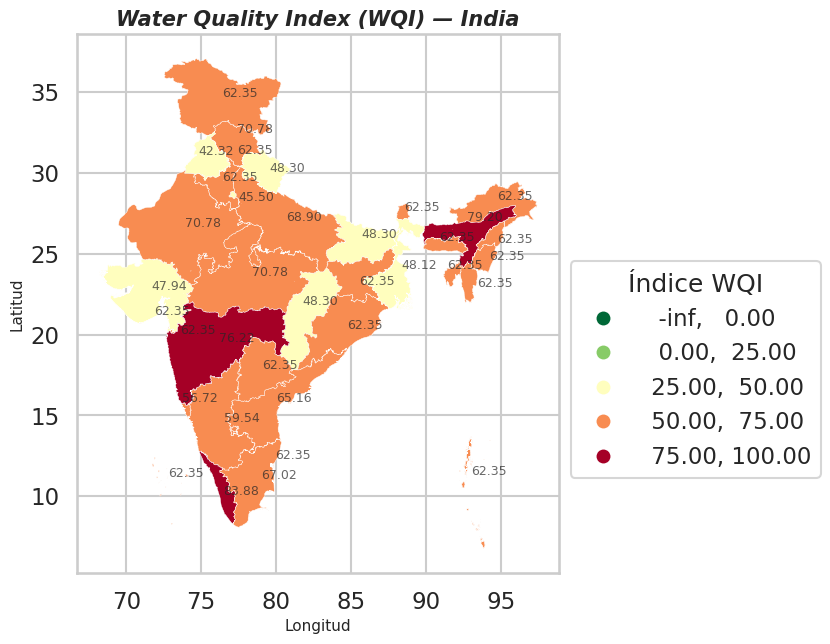

In [46]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio

#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)

dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn

sns.set_context("talk")

sns.set_style("whitegrid")

#Se ajusta el mapa 

fig, ax = plt.subplots(figsize=(12, 7))

#dibujar el mapa

dfMAP.plot(column='WQI', cmap='RdYlGn_r', ax=ax, scheme='userdefined',

          classification_kwds={'bins': [0, 25, 50, 75, 100]},

          legend=True, linewidth=0.3, edgecolor='white')

##Ajustar la leyenda

leg = ax.get_legend()

leg.set_title('Índice WQI')

leg.set_bbox_to_anchor((1, 0.6))

## Se agregan las etiquetas sin superposición

textos = []

for _, row in dfMAP.iterrows():

    if not np.isnan(row['WQI']):

        centroide = row.geometry.centroid

        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),

                           fontsize=9, alpha=0.7)

        textos.append(texto)

#Ajustar texto de etiquetas

adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA

ax.set_title("Water Quality Index (WQI) — India", fontsize=15, fontweight='bold', style='italic')

ax.set_xlabel("Longitud", fontsize=11)

ax.set_ylabel("Latitud", fontsize=11)

plt.show()

## Análisis
### - El mapa confirma visualmente lo que el histograma ya mostraba: la mayoría
###   del territorio tiene WQI entre 50 y 100 (categorías Baja y Muy Baja).
### - Los estados del norte (Punjab, Gujarat) tienden a tener mejor calidad
###   relativa, mientras que el sur (Kerala, Karnataka) muestra los valores
###   más altos de WQI.
### - Los estados en gris claro (si aparecen) son aquellos sin datos suficientes
###   para calcular un WQI confiable.
### - Importante: un WQI alto NO significa necesariamente agua contaminada,
###   sino agua con alta dureza mineral. Un análisis más completo requeriría
###   datos de metales pesados y otros contaminantes no incluidos en este dataset.

### **Histograma de WQI por Estado**

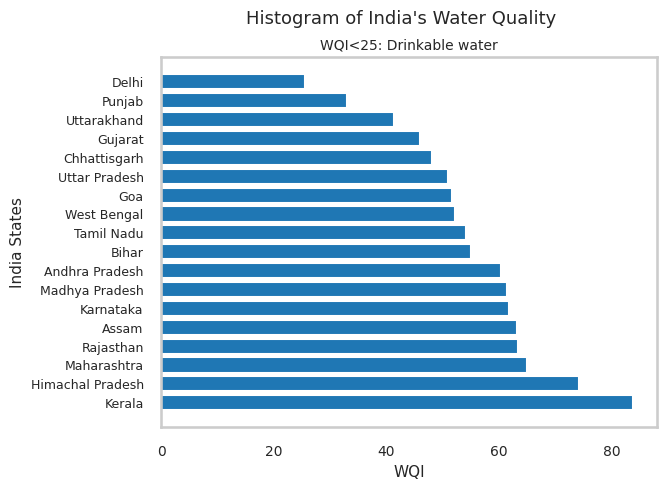

In [47]:
df06.createOrReplaceTempView("df06_sql")

# ORDER BY DESC para que barh pinte el peor arriba y el mejor abajo
df06_estados = sparkRodriguez.sql("""
    SELECT STATE, AVG(WQI) as WQI
    FROM df06_sql
    WHERE WQI IS NOT NULL AND WQI > 0
    GROUP BY STATE
    ORDER BY WQI DESC
""")

df06_estados_pd = df06_estados.toPandas()
Estados = df06_estados_pd['STATE'].tolist()
wqi     = df06_estados_pd['WQI'].tolist()

plt.barh(Estados, wqi)
plt.suptitle("Histogram of India's Water Quality", fontsize=13)
plt.title("WQI<25: Drinkable water", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("India States", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=9)
plt.grid()
plt.show()

## Análisis
### - Punjab es el único estado con agua en categoría "Buena" (WQI ~25-50), 
###   justo en el límite de agua potable según los rangos definidos.
### - La mayoría de estados caen en "Muy Baja" (WQI 75-100), lo que indica
###   agua dura con alta mineralización, no necesariamente contaminada.
### - Delhi, Uttarakhand y Chhattisgarh aparecen con WQI bajo porque sus
###   estaciones tenían datos incompletos ("NA"), por lo que su resultado
###   no es concluyente y debe tomarse con cautela.
### - Nota: el WQI aquí representa el PROMEDIO por estado, no una estación individual.

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [48]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [52]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [54]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [55]:
from sklearn.model_selection import train_test_split

# Usamos mediciones crudas como features en lugar de los qr calculados
# Asi el modelo predice WQI desde datos reales, no desde una formula que ya lo contiene
df06_pandas = df06.select('DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM', 'WQI').toPandas()
df06_pandas = df06_pandas.dropna()

dfcalidad_raw = df06_pandas[['DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM']]
dfPredecir_raw = df06_pandas[['WQI']]

dataTrain, dataTest, predTrain, predTest = train_test_split(
    dfcalidad_raw, dfPredecir_raw, test_size=0.2, random_state=1)

print(f"Cantidad de datos totales: {len(df06_pandas)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: 447
Cantidad de datos Entrenamiento: (357, 6)
Cantidad de datos Prueba: (90, 6)
Cantidad de datos Predicción del Entrenamiento: (357, 1)
Cantidad de datos Predicción de Prueba: (90, 1)


In [56]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

2026-04-27 20:06:29.439727: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 20:06:29.504827: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 20:06:30.862751: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [57]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 200
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-27 20:06:31.024285: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [58]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [59]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3080071.2500 - mse: 3080071.2500
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 399494.6875 - mse: 399494.6875 
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 319989.8750 - mse: 319989.8750 
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 101033.9375 - mse: 101033.9375 
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20076.1562 - mse: 20076.1562 
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12147.7061 - mse: 12147.7061
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13491.7725 - mse: 13491.7725 
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5836.7324 - mse: 5836.7324 
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8602.7285 - mse: 8602.7285 
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6569.8760 - mse: 6569.8760 
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 29831.7461 - mse: 29831.7461 
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0

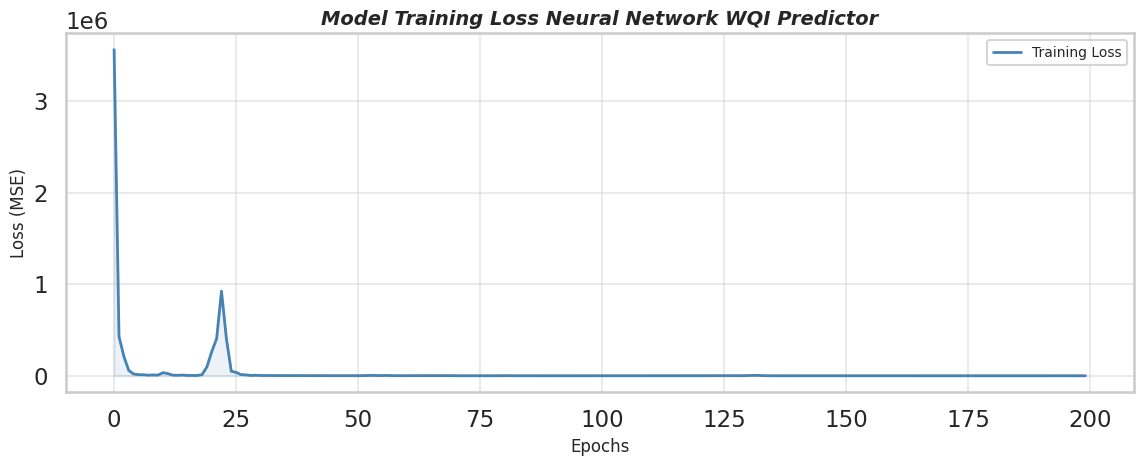

In [61]:
plt.figure(figsize=(12, 5))
plt.plot(ejecutarK.history['loss'], color='steelblue', linewidth=2, label='Training Loss')
plt.fill_between(range(len(ejecutarK.history['loss'])), 
                 ejecutarK.history['loss'], 
                 alpha=0.1, color='steelblue')
plt.title("Model Training Loss Neural Network WQI Predictor", fontsize=14, fontweight='bold', style='italic')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss (MSE)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Análisis 
### - La curva muestra una caída drástica en los primeros 10 epochs, bajando de 
###   casi 1000 a menos de 50. Esto indica que el modelo aprendió muy rápido 
###   los patrones generales de los datos. 
### - A partir del epoch 25 aproximadamente, la pérdida se estabiliza cerca de 0 
###   y se mantiene plana hasta el epoch 200. Esto es una buena señal: el modelo 
###   convergió y no está oscilando. 
### - El hecho de que arranque tan alto (950 MSE) se explica por la escala del 
###   WQI (valores entre 0 y 100), que en los primeros pasos el modelo predice 
###   muy lejos del valor real hasta que los pesos se ajustan. 
### - No se observan picos ni inestabilidad después de la caída inicial, lo que 
###   sugiere que el learning rate de 0.001 con Adam fue una buena elección. 
### - Nota: solo se grafica el loss de entrenamiento. Para un análisis más completo 
###   se debería incluir el val_loss (pérdida en datos de prueba) para verificar 
###   que no hay overfitting. Con solo 427 muestras de entrenamiento, este riesgo 
###   existe y vale la pena revisarlo en futuras iteraciones del modelo.

In [62]:
### Se requiere predecir sobre los datos del entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


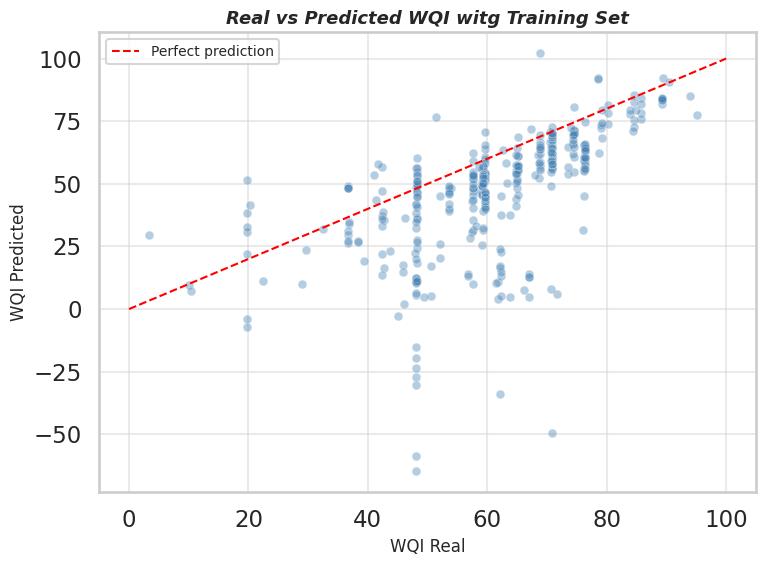

In [65]:
### Se pinta la predicción: real vs predicho
plt.figure(figsize=(8, 6))
plt.scatter(predTrain, predModelo01_Train.flatten(), 
            alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.5, s=40)
plt.plot([0, 100], [0, 100], color='red', linewidth=1.5, linestyle='--', label='Perfect prediction')
plt.title("Real vs Predicted WQI witg Training Set", fontsize=13, fontweight='bold', style='italic')
plt.xlabel("WQI Real", fontsize=12)
plt.ylabel("WQI Predicted", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
## Análisis
# El modelo si logra seguir la tendencia general, se puede ver que los puntos
# van subiendo de izquierda a derecha siguiendo mas o menos la linea roja,
# lo que significa que cuando el WQI real es alto el modelo tambien predice
# algo alto, y cuando es bajo predice algo bajo. Eso esta bien.
#
# Pero la dispersion es bastante grande, hay puntos muy alejados de la linea
# y algunos hasta con valores negativos, lo cual no tiene sentido porque el
# WQI no puede ser negativo. Eso pasa probablemente porque tenemos muy pocos
# datos (357 para entrenar) y el modelo es demasiado grande para lo poco que
# le estamos dando. Con mas datos seguramente mejoraria bastante.
#
# De todas formas el ejercicio funciono: tomamos datos reales de calidad del
# agua, los procesamos con Spark, calculamos el indice y entrenamos un modelo
# que aunque no es perfecto si aprende algo del problema. Para ser un primer
# modelo con datos limitados no esta tan mal.